In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models,regularizers,callbacks,optimizers
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.utils import plot_model

In [4]:
print(tf.__version__)

2.21.0


In [3]:
import kagglehub

path = kagglehub.dataset_download("oxcdcd/cifar10")
 
print("Path to dataset files:", path)

c:\Users\HP\Desktop\project\cnnenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\HP\.cache\kagglehub\datasets\oxcdcd\cifar10\versions\1


In [4]:
train_path = path+'/cifar10/train'
test_path = path+'/cifar10/test'

In [5]:
classes = ['airplane','automobile','bird',
            'cat','deer','dog','frog','horse','ship','truck']

In [6]:
num_classes = len(classes)

In [7]:
train_dataset,val_dataset = image_dataset_from_directory(train_path,image_size=(32,32),subset='both',validation_split=0.2,seed=42)

Found 50000 files belonging to 10 classes.
Using 40000 files for training.
Using 10000 files for validation.


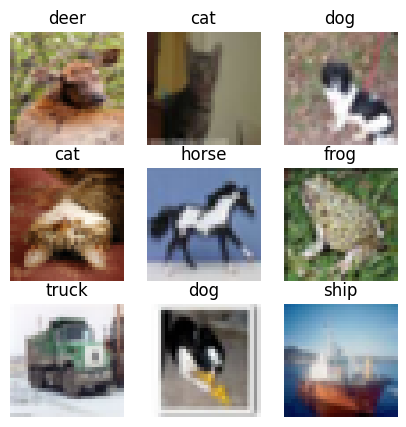

In [8]:
plt.figure(figsize=(5,5))
for images,labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(classes[int(labels[i])])
        plt.axis("off")


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(0.1, 0.1),
])

def conv_block(x, filters, dropout_rate=0.0):
    x = layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D((2, 2))(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    return x


def build_improved_cnn():
    inputs = keras.Input(shape=(32, 32, 3))

    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)

    x = conv_block(x, filters=64, dropout_rate=0.15)
    x = conv_block(x, filters=128, dropout_rate=0.25)
    x = conv_block(x, filters=256, dropout_rate=0.35)
    x = conv_block(x, filters=512, dropout_rate=0.45)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes)(x)

    model_exp3 = keras.Model(inputs, outputs, name="model_exp3")
    return model_exp3


model_exp3 = build_improved_cnn()

keras.utils.plot_model(model_exp3, show_shapes=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [ ]:
epochs = 50

callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3
    )
]


model_exp3.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3,weight_decay=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(
    name="sparse_categorical_accuracy")],
)
history_exp3 = model_exp3.fit(
    train_dataset,
    epochs=epochs,
    validation_data=val_dataset,
    callbacks=callbacks_list
)

Epoch 1/20


1045/1250 ━━━━━━━━━━━━━━━━━━━━ 1:25 417ms/step - loss: 2.4342 - sparse_categorical_accuracy: 0.2113

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(history_exp3.history['loss'],label='train')
plt.plot(history_exp3.history['val_loss'],label='val')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(history_exp3.history['sparse_categorical_accuracy'],label='train')
plt.plot(history_exp3.history['val_sparse_categorical_accuracy'],label='val')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
MODEL_PATH = "final_cifar10_cnn.keras"

model_exp3.save(MODEL_PATH)

print("Model saved at:", MODEL_PATH)

In [ ]:
MODEL_PATH = "improved_cifar10_cnn.keras"
loaded_model = keras.models.load_model(MODEL_PATH)

print("Model loaded successfully!")
loaded_model.summary()

In [ ]:
img = keras.utils.load_img(path+'/cifar10/test/frog/1034_frog.png', target_size=(32,32))
plt.imshow(img)

img_array = keras.utils.img_to_array(img)
print(img_array.shape)
img_array = keras.ops.expand_dims(img_array, 0)  # Create batch axis
print(img_array.shape)
predictions = loaded_model.predict(img_array)
out_idx = keras.ops.argmax(predictions, axis=1)
print(f"This image is {classes[int(out_idx)]}")